In [16]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

In [17]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [18]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [19]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats

score_dict = defaultdict(list)

open_access_lookup_0 = {
    "Optica": "Hybrid (subscription + open access)",
    "Photonics Research": "Fully open access",
    "Biomedical Optics Express": "Fully open access",
    "Optics Express": "Fully open access",
    "Optics Letters": "Hybrid (subscription + open access)",
    "Applied Optics": "Hybrid (subscription + open access)",
    "Journal of the Optical Society of America B": "Hybrid (subscription + open access)",
    "Optical Materials Express": "Fully open access",
    "Optics Continuum": "Fully open access",
    "Frontiers in Bioengineering and Biotechnology": "Fully open access",
    "Frontiers in Chemistry": "Fully open access",
    "Frontiers in Energy Research": "Fully open access",
    "Frontiers in Nanotechnology": "Fully open access",
    "Frontiers in Chemical Engineering": "Fully open access",
    "Frontiers in Materials": "Fully open access",
    "Frontiers in Physics": "Fully open access",
    "Mini-Reviews in Organic Chemistry": "Hybrid (subscription + open access)",
    "Current Organic Chemistry": "Hybrid (subscription + open access)",
    "Current Nanoscience": "Hybrid (subscription + open access)",
    "Current Organocatalysis": "Hybrid (subscription + open access)",
    "E3S Web of Conferences": "Fully open access",
    "MATEC Web of Conferences": "Fully open access",
    "EPJ Web of Conferences": "Fully open access",
    "Astronomy & Astrophysics": "Hybrid (subscription + open access)",
    "Journal of the European Optical Society-Rapid Publications": "Fully open access",
    "Metallurgical Research & Technology": "Hybrid (subscription + open access)",
    "SSRN Electronic Journal": "Fully open access (preprint)",
    "Accounts of Materials Research": "Hybrid (subscription + open access)",
    "ACS Energy Letters": "Hybrid (subscription + open access)",
    "Nature": "Hybrid (subscription + open access)",
    "Nature Energy": "Hybrid (subscription + open access)",
    "Nature Communications": "Fully open access",
    "Nano-Micro Letters": "Fully open access",
    "Materials Science": "Hybrid (subscription + open access)",
    "Biomedical Microdevices": "Hybrid (subscription + open access)",
    "Medicinal Chemistry Research": "Hybrid (subscription + open access)",
    "Journal of Materials Science: Materials in Electronics": "Hybrid (subscription + open access)",
    "Scientific Reports": "Fully open access",
    "2D Materials": "Fully open access",
    "Quantum Science and Technology": "Fully open access",
    "Journal of Physics: Photonics": "Fully open access",
    "Nanotechnology": "Hybrid (subscription + open access)",
    "Journal of Physics: Condensed Matter": "Hybrid (subscription + open access)",
    "Smart Materials and Structures": "Hybrid (subscription + open access)",
    "Journal of Physics Energy": "Fully open access",
    "Journal of Semiconductors": "Fully open access",
    "IOP Conference Series: Materials Science and Engineering": "Fully open access",
    "Accounts of Materials Research": "Hybrid (subscription + open access)",
    "Environmental Science and Technology": "Hybrid (subscription + open access)",
    "ACS Applied Materials & Interfaces": "Hybrid (subscription + open access)",
    "ACS Omega": "Fully open access",
    "The Journal of Physical Chemistry C": "Hybrid (subscription + open access)",
    "Inorganic Chemistry": "Hybrid (subscription + open access)",
    "JACS Au": "Fully open access",
    "ACS ES&T Engineering": "Hybrid (subscription + open access)",
    "Journal of Medicinal Chemistry": "Hybrid (subscription + open access)",
    "Journal of The American Society for Mass Spectrometry": "Hybrid (subscription + open access)",
    "ChemRxiv": "Fully open access (preprint)",
    "Physical Review X": "Fully open access",
    "PRX Quantum": "Fully open access",
    "Physical Review Letters": "Hybrid (subscription + open access)",
    "Physical Review Research": "Fully open access",
    "Physical Review C": "Hybrid (subscription + open access)",
    "Physical Review B": "Hybrid (subscription + open access)",
    "Physical Review A": "Hybrid (subscription + open access)",
    "Physical Review Materials": "Fully open access",
    "Physical Review Applied": "Fully open access",
    "Physical Review E": "Hybrid (subscription + open access)",
    "Physical Review D": "Hybrid (subscription + open access)",
    "International Journal of Nanomedicine": "Fully open access",
    "Materials Research Letters": "Hybrid (subscription + open access)",
    "Green Chemistry Letters and Reviews": "Fully open access",
    "Science and Technology of Advanced Materials": "Fully open access",
    "Nanotoxicology": "Hybrid (subscription + open access)",
    "Waves in Random and Complex Media": "Hybrid (subscription + open access)",
    "Polycyclic Aromatic Compounds": "Hybrid (subscription + open access)",
    "Molecular Physics": "Hybrid (subscription + open access)",
    "Liquid Crystals": "Hybrid (subscription + open access)",
    "Journal of Macromolecular Science Part B": "Hybrid (subscription + open access)",
    "Advanced Composite Materials": "Hybrid (subscription + open access)",
    "Analytical Letters": "Hybrid (subscription + open access)",
    "Journal of Asian Ceramic Societies": "Hybrid (subscription + open access)",
    "Molecular Crystals and Liquid Crystals": "Hybrid (subscription + open access)",
    "Ferroelectrics": "Hybrid (subscription + open access)",
    "Current Organic Synthesis": "Hybrid (subscription + open access)",
    "Current Organic Chemistry": "Hybrid (subscription + open access)",
    "Mini-Reviews in Organic Chemistry": "Hybrid (subscription + open access)",
    "Current Nanoscience": "Hybrid (subscription + open access)",
    "Letters in Organic Chemistry": "Hybrid (subscription + open access)",
    "Current Organocatalysis": "Hybrid (subscription + open access)",
    "Nano-Micro Letters": "Fully open access",
    "Journal of Materials Science: Materials in Electronics": "Hybrid (subscription + open access)",
    "Nature Communications": "Fully open access",
    "Scientific Reports": "Fully open access",
    "Biomedical Microdevices": "Hybrid (subscription + open access)",
    "Medicinal Chemistry Research": "Hybrid (subscription + open access)",
    "Materials Science": "Hybrid (subscription + open access)",
    "eScience": "Fully open access",
    "Marine Drugs": "Fully open access",
    "Nanomaterials": "Fully open access",
    "Polymers": "Fully open access (MDPI)",
    "Actuators": "Fully open access (MDPI)",
    "Membranes": "Fully open access (MDPI)",
    "Molecules": "Fully open access (MDPI)",
    "Materials": "Fully open access (MDPI)",
    "Crystals": "Fully open access (MDPI)",
    "Coatings": "Fully open access (MDPI)",
    "Catalysts": "Fully open access (MDPI)",
    "Sensors": "Fully open access (MDPI)",
    "Reactions": "Fully open access (MDPI)",
    "The Journal of Physical Chemistry C": "Hybrid (subscription + open access)",
    "Advanced Energy Materials": "Hybrid (subscription + open access)",
    "InfoMat": "Fully open access",
    "Advanced Materials": "Hybrid (subscription + open access)",
    "Carbon Energy": "Fully open access",
    "Angewandte Chemie International Edition": "Hybrid (subscription + open access)",
    "Advanced Functional Materials": "Hybrid (subscription + open access)",
    "Small": "Hybrid (subscription + open access)",
    "Chemistry - A European Journal": "Hybrid (subscription + open access)",
    "physica status solidi (RRL) - Rapid Research Letters": "Hybrid (subscription + open access)",
    "Microscopy Research and Technique": "Hybrid (subscription + open access)",
    "Polymer Composites": "Hybrid (subscription + open access)",
    "Chirality": "Hybrid (subscription + open access)",
    "Journal of Physical Organic Chemistry": "Hybrid (subscription + open access)",
    "Angewandte Chemie": "Hybrid (subscription + open access)",
    "ChemistrySelect": "Fully open access",
    "Batteries & Supercaps": "Fully open access",
    "Ce/Papers": "Fully open access",
    "Chemistry - A European Journal": "Hybrid (subscription + open access)",
    "Advanced Functional Materials": "Hybrid (subscription + open access)",
    "Energy & Environmental Science": "Hybrid (subscription + open access)",
    "Journal of Materials Chemistry A": "Hybrid (subscription + open access)",
    "Environmental Science: Nano": "Hybrid (subscription + open access)",
    "Materials Horizons": "Hybrid (subscription + open access)",
    "Chemical Science": "Fully open access",
    "Physical Chemistry Chemical Physics": "Hybrid (subscription + open access)",
    "Chemical Communications": "Hybrid (subscription + open access)",
    "Dalton Transactions": "Hybrid (subscription + open access)",
    "RSC Advances": "Fully open access",
    "New Journal of Chemistry": "Hybrid (subscription + open access)",
    "Nanoscale Advances": "Fully open access",
    "Digital Discovery": "Fully open access",
    "Energy Advances": "Fully open access",
    "Biomaterials Science": "Fully open access",
    "Analyst": "Hybrid (subscription + open access)",
    "Applied Physics Reviews": "Hybrid (subscription + open access)",
    "APL Photonics": "Hybrid (subscription + open access)",
    "The Journal of Chemical Physics": "Hybrid (subscription + open access)",
    "Applied Physics Letters": "Hybrid (subscription + open access)",
    "APL Materials": "Hybrid (subscription + open access)",
    "Journal of Applied Physics": "Hybrid (subscription + open access)",
    "AIP Advances": "Fully open access",
    "Review of Scientific Instruments": "Hybrid (subscription + open access)",
    "Low Temperature Physics": "Hybrid (subscription + open access)",
    "Chinese Journal of Chemical Physics": "Hybrid (subscription + open access)",
    "Physics of Plasmas": "Hybrid (subscription + open access)",
    "Structural Dynamics": "Fully open access",
    "Journal of Mathematical Physics": "Hybrid (subscription + open access)",
    "IOP Conference Series: Materials Science and Engineering": "Fully open access",
    "Scientific Data": "Fully open access",
    "Journal of Open Source Software (JOSS)": "Fully open access",
    "Data Science Journal": "Fully open access",
    "The Journal of Organic Chemistry": "Fully open access",
    "jacs": "Hybrid",
    "applied_materials_and_interfaces": "Hybrid",
    "acs_es_and_t_engineering": "Gold Open Access",
    "accounts_of_chemical_research": "Hybrid",
    "physics_of_fluids": "Hybrid",
    "optical_materials": "Hybrid",
    "applied_catalysis_b_environment_and_energy": "Gold Open Access",
    "chemical_engineering_journal": "Hybrid",
    "energy_storage_materials": "Gold Open Access",
    "materials_today_proceedings": "Open Access Proceedings",
    "international_journal_of_thermal_sciences": "Hybrid",
    "composites_science_and_technology": "Hybrid",
    "ieee_transactions_on_ultrasonics_ferroelectrics_and_frequency_control": "Hybrid",
    "ieee_photonics_journal": "Gold Open Access",
    "ieee_transactions_on_industrial_electronics": "Hybrid",
    "ieee_transactions_on_transportation_electrification": "Hybrid",
    "ieee_transactions_on_applied_superconductivity": "Hybrid",
    "journal_of_lightwave_technology": "Hybrid",
    "ieee_robotics_and_automation_letters": "Hybrid",
    "ieee_sensors_letters": "Hybrid",
    "ieee_journal_of_photovoltaics": "Hybrid",
    "ieee_transactions_on_dielectrics_and_electrical_insulation": "Hybrid",
    "ieee_journal_of_selected_topics_in_quantum_electronics": "Hybrid",
    "ieee_transactions_on_electron_devices": "Hybrid",
    "ieee_sensors_journal": "Hybrid",
    "ieee_electron_device_letters": "Hybrid",
    "ieee_access": "Gold Open Access",
    "journal_of_physics_photonics": "Gold Open Access",
    "iop_conference_series_materials_science_and_engineering": "Open Access Proceedings",
    "journal_of_physics_condensed_matter": "Hybrid",
    "photonics": "Gold Open Access",
    "molbank": "Gold Open Access",
    "batteries": "Gold Open Access",
    "russian_journal_of_organic_chemistry": "Hybrid",
    "physical_mesomechanics": "Hybrid",
    "russian_journal_of_physical_chemistry_a": "Hybrid",
    "membranes_and_membrane_technologies": "Hybrid",
    "atmospheric_and_oceanic_optics": "Hybrid",
    "russian_journal_of_general_chemistry": "Hybrid",
    "journal_of_experimental_and_theoretical_physics": "Hybrid",
    "physics_of_metals_and_metallography": "Hybrid",
    "russian_journal_of_inorganic_chemistry": "Hybrid",
    "environmental_science_nano": "Hybrid",
    "energy_and_environmental_science": "Hybrid",
    "journal_of_materials_science_materials_in_electronics": "Hybrid",
    "high_energy_chemistry": "Hybrid",
    "batteries_and_supercaps": "Hybrid",
    "ce-papers": "Gold Open Access",
    "chemistry_a_european_journal": "Hybrid"
}

value_lookup = {
    "Fully open access": "Open access",
    "Gold Open Access": "Open access",
    "Fully open access (MDPI)": "Open access",
    "Open Access Proceedings": "Open access",
    "Fully open access (preprint)": "Open access",
    "Hybrid (subscription + open access)": "Hybrid",
    "Hybrid": "Hybrid",
}

open_access_lookup = {}
for key, value in open_access_lookup_0.items():
    key_new = key.replace(" ", "_")
    open_access_lookup[key_new.lower()] = value_lookup[value]

open_access_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():
        score = get_journal_score(journal_results)
        score_list.append(score)  # append the score
        open_access_list.append(open_access_lookup[journal])

# Convert to DataFrame for easier plotting
df = pd.DataFrame({
    'Policy Score': score_list,
    'Open Access': open_access_list
})

# Compute means
means = df.groupby('Open Access')['Policy Score'].mean()

# ANOVA test
open_access = df[df['Open Access'] == "Open access"]['Policy Score']
hybrid = df[df['Open Access'] == "Hybrid"]['Policy Score']

f_val, p_val = stats.f_oneway(open_access, hybrid)
print(f"ANOVA F-statistic: {f_val:.3f}, p-value: {p_val:.3e}")

t_stat_1, p_val_1 = stats.ttest_ind(open_access, hybrid, equal_var=False)
print(f"T-test: {t_stat_1:.3f}, p-value: {p_val_1:.3e}")
            

ANOVA F-statistic: 19.702, p-value: 1.628e-05
T-test: 4.099, p-value: 8.154e-05


/tmp/ipykernel_13232/233139380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_13232/233139380.py:7: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.violinplot(


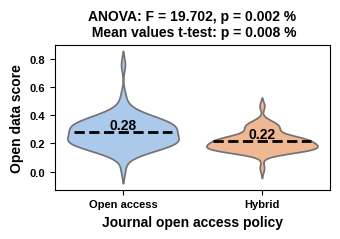

In [20]:
fig = plt.figure(figsize=(3.5, 2.5))

palette = sns.color_palette("pastel")

plt.title(f"ANOVA: F = {f_val:.3f}, p = {p_val*100:.3f} %\n Mean values t-test: p = {p_val_1*100:.3f} %")

sns.violinplot(
    x='Open Access',
    y='Policy Score',
    data=df,
    palette=palette,
    inner=None,
    #inner='point'
)

# Add text labels for the means
for i, val in enumerate(means):
    violin_width = 0.8  # default width in sns.violinplot
    plt.hlines(
        y=val,
        xmin=1 - i - violin_width/2 + 0.05,
        xmax=1 - i + violin_width/2 - 0.05,
        colors='black',
        linewidth=2,
        linestyle='--'
    )

    plt.text(
        1-i,              # x position (0 for False, 1 for True)
        val + 0.02,     # y position slightly above the mean
        f'{val:.2f}',   # text with 2 decimal places
        horizontalalignment='center',
        fontweight='bold'
    )

plt.xlabel("Journal open access policy")
plt.ylabel("Open data score")
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_open_access.pdf")